# 1. Importación de librerías

In [13]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score
import warnings

# 2. Carga del Dataset de Resultados

In [14]:
df_results = pd.read_csv('../metrics/model_comparison_ranking.csv')
df_sorted = df_results.sort_values('MAE')
df_sorted

,Model,MAE,RMSE,R2,MAPE,Time_sec
0,SVR,1.395809,1.855811,0.285788,0.017144,0.068334
1,CatBoost,1.421123,1.862346,0.280749,0.017383,0.467199
2,LinearRegression,1.427794,1.874801,0.271097,0.017482,0.029725
3,Voting_Ensemble,1.451937,1.917729,0.237335,0.017757,1.018958
4,XGBoost,1.464725,1.934979,0.223552,0.017922,0.128405
5,GradientBoosting,1.471929,1.931665,0.226209,0.017997,0.373894
6,RandomForest,1.488237,1.955429,0.207053,0.018194,0.616376


# 3. Comparativa de modelos (MAE)

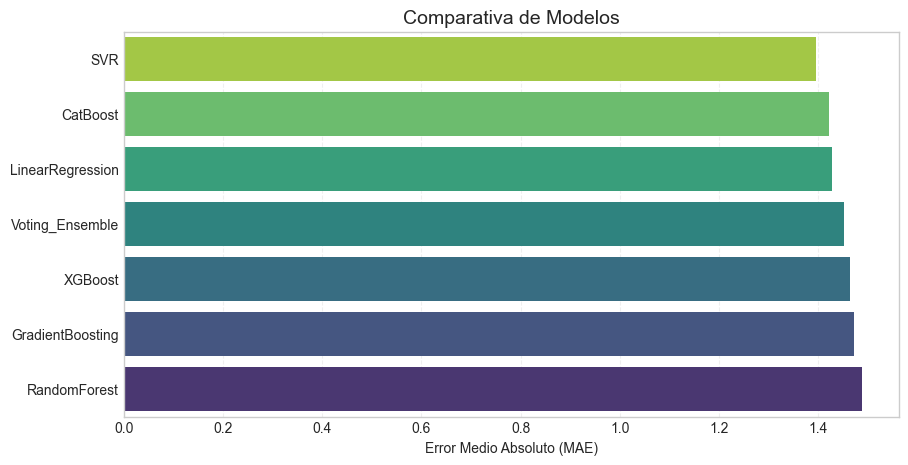

In [15]:
warnings.filterwarnings('ignore')
plt.figure(figsize=(10, 5))
df_for_plot = df_sorted.iloc[::-1] 
sns.barplot(x='MAE', y='Model', data=df_for_plot, palette='viridis', hue='Model', legend=False)
plt.gca().invert_yaxis() 
plt.title('Comparativa de Modelos', fontsize=14)
plt.xlabel('Error Medio Absoluto (MAE)')
plt.ylabel('') 
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# 4. Precisión del Modelo SVR

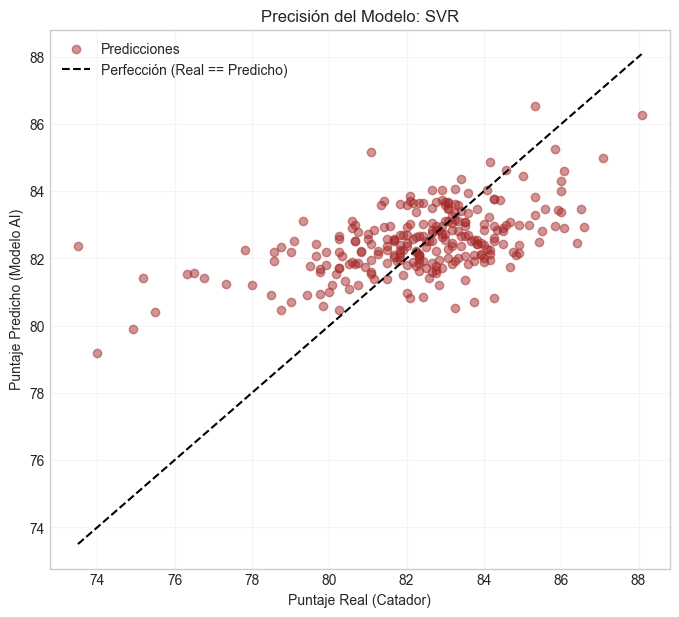

 Análisis finalizado para SVR. MAE: 1.3958


In [16]:
base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
path_data = os.path.join(base_path, "data", "processed", "coffee_data_for_training.csv")
path_metrics = os.path.join(base_path, "metrics", "model_comparison_ranking.csv")
path_models = os.path.join(base_path, "models", "prediction")

df = pd.read_csv(path_data)
target = 'Total.Cup.Points'
features_cat = ['Country.of.Origin', 'Region', 'Variety', 'Processing.Method', 'Color', 'categoria_altitud']
features_num = ['Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'altitude_mean_meters']

X = df[features_cat + features_num]
y = df[target]

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if os.path.exists(path_metrics):
    df_results = pd.read_csv(path_metrics)
    best_model_name = df_results.iloc[0]['Model']
    model_file = os.path.join(path_models, f"coffee_model_{best_model_name}.pkl")


    best_model = joblib.load(model_file)
    y_pred = best_model.predict(X_test)


    plt.figure(figsize=(8, 7))
    plt.scatter(y_test, y_pred, alpha=0.5, color='brown', label='Predicciones')
    

    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'k--', lw=1.5, label='Perfección (Real == Predicho)') 
    
    plt.xlabel('Puntaje Real (Catador)')
    plt.ylabel('Puntaje Predicho (Modelo AI)')
    plt.title(f'Precisión del Modelo: {best_model_name}')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f" Análisis finalizado para {best_model_name}. MAE: {mean_absolute_error(y_test, y_pred):.4f}")
else:
    print(" Error: No se encontró el ranking en /metrics. Ejecutá el entrenamiento primero.")

# 5. Matriz de Confusión SVR (Umbral Media)

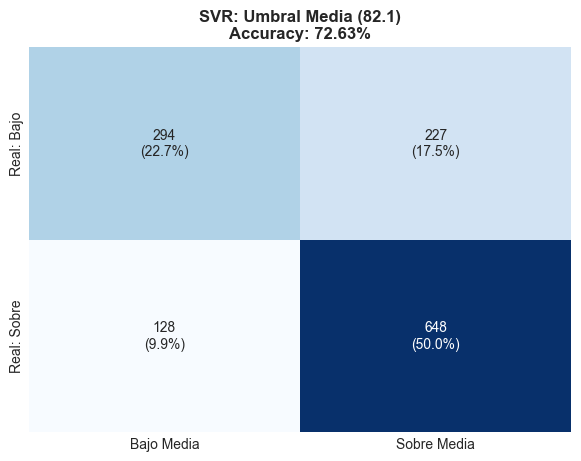

In [17]:
model_svr = joblib.load('../models/prediction/coffee_model_SVR.pkl')

umbral_media = 82.1
y_real_media = (df['Total.Cup.Points'] >= umbral_media).astype(int)
y_pred_media = (model_svr.predict(X) >= umbral_media).astype(int)

cm_media = confusion_matrix(y_real_media, y_pred_media)
pct_media = cm_media.astype('float') / cm_media.sum()

labels_media = [f"{v}\n({p:.1%})" for v, p in zip(cm_media.flatten(), pct_media.flatten())]
labels_media = np.asarray(labels_media).reshape(2,2)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_media, annot=labels_media, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Bajo Media', 'Sobre Media'],
            yticklabels=['Real: Bajo', 'Real: Sobre'])

plt.title(f'SVR: Umbral Media ({umbral_media})\nAccuracy: {accuracy_score(y_real_media, y_pred_media):.2%}', fontweight='bold')
plt.show()

# 6. Matriz de Confusión SVR (Umbral Mediana)

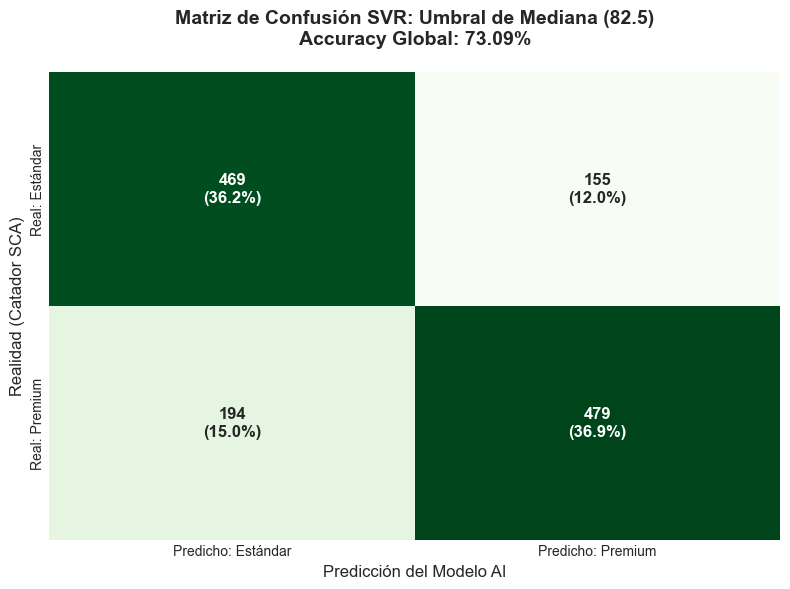

In [18]:
umbral_mediana = 82.5
y_real_mediana = (df['Total.Cup.Points'] >= umbral_mediana).astype(int)
y_pred_mediana = (model_svr.predict(X) >= umbral_mediana).astype(int)

cm_mediana = confusion_matrix(y_real_mediana, y_pred_mediana)
pct_mediana = cm_mediana.astype('float') / cm_mediana.sum()

labels_mediana = [f"{int(v)}\n({p:.1%})" for v, p in zip(cm_mediana.flatten(), pct_mediana.flatten())]
labels_finales = np.array(labels_mediana).reshape(2,2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mediana, annot=labels_finales, fmt='', cmap='Greens', cbar=False,
            xticklabels=['Predicho: Estándar', 'Predicho: Premium'],
            yticklabels=['Real: Estándar', 'Real: Premium'],
            annot_kws={"size": 12, "weight": "bold"})

plt.xlabel('Predicción del Modelo AI', fontsize=12)
plt.ylabel('Realidad (Catador SCA)', fontsize=12)
plt.title(f'Matriz de Confusión SVR: Umbral de Mediana ({umbral_mediana})\n'
          f'Accuracy Global: {accuracy_score(y_real_mediana, y_pred_mediana):.2%}', 
          fontsize=14, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

# 7. Diagnóstico de Errores SVR

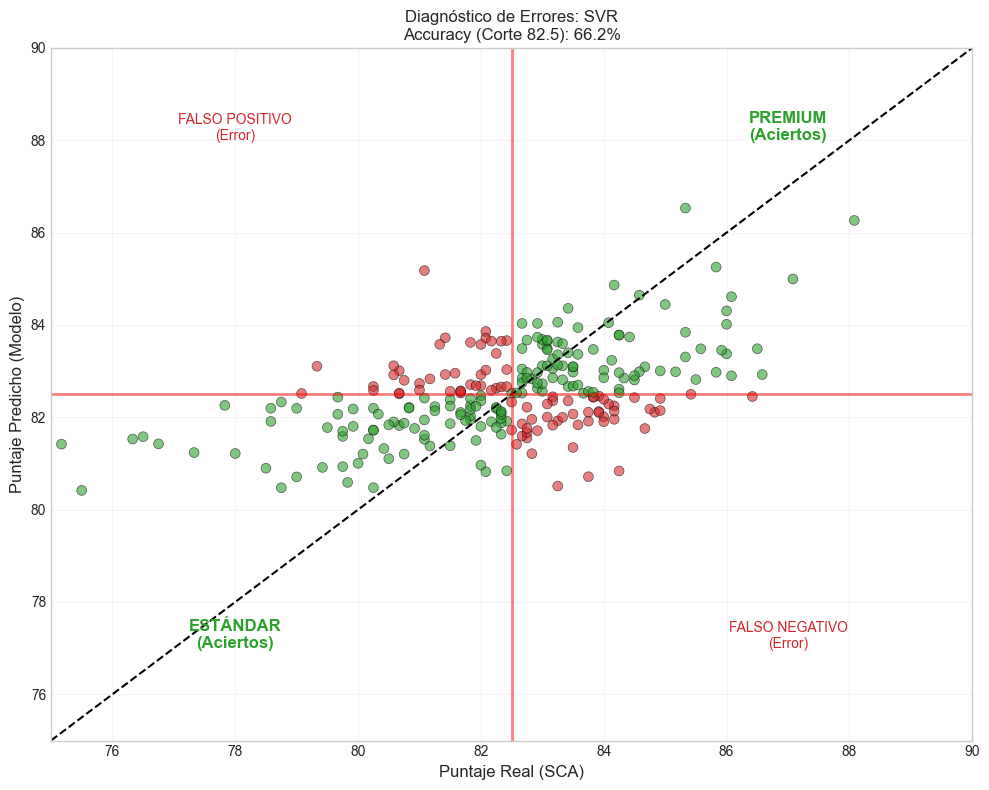

In [19]:
base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
path_data = os.path.join(base_path, "data", "processed", "coffee_data_for_training.csv")
path_metrics = os.path.join(base_path, "metrics", "model_comparison_ranking.csv")
path_models = os.path.join(base_path, "models", "prediction")

df = pd.read_csv(path_data)
df = df[(df['Total.Cup.Points'] > 70) & (df['Total.Cup.Points'] < 92)]

target = 'Total.Cup.Points'
features_cat = ['Country.of.Origin', 'Region', 'Variety', 'Processing.Method', 'Color', 'categoria_altitud']
features_num = ['Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'altitude_mean_meters']

X = df[features_cat + features_num]
y = df[target]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df_results = pd.read_csv(path_metrics)
best_model_name = df_results.iloc[0]['Model']
model_file = os.path.join(path_models, f"coffee_model_{best_model_name}.pkl")
best_model = joblib.load(model_file)
y_pred = best_model.predict(X_test)

umbral = 82.5
y_test_bin = (y_test >= umbral).astype(int)
y_pred_bin = (y_pred >= umbral).astype(int)
colores = np.where(y_test_bin == y_pred_bin, '#2ca02c', '#d62728') 

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, c=colores, s=50, edgecolors='k', linewidths=0.5)

lims = [75, 90]
plt.plot(lims, lims, 'k--', lw=1.5, label='Perfección (Real == Predicho)')
plt.axhline(umbral, color='red', linestyle='-', alpha=0.5, lw=2)
plt.axvline(umbral, color='red', linestyle='-', alpha=0.5, lw=2)

plt.text(87, 88, 'PREMIUM\n(Aciertos)', color='#2ca02c', fontsize=12, fontweight='bold', ha='center')
plt.text(78, 77, 'ESTÁNDAR\n(Aciertos)', color='#2ca02c', fontsize=12, fontweight='bold', ha='center')
plt.text(87, 77, 'FALSO NEGATIVO\n(Error)', color='#d62728', fontsize=10, ha='center')
plt.text(78, 88, 'FALSO POSITIVO\n(Error)', color='#d62728', fontsize=10, ha='center')

plt.xlabel('Puntaje Real (SCA)', fontsize=12)
plt.ylabel('Puntaje Predicho (Modelo)', fontsize=12)
plt.title(f'Diagnóstico de Errores: {best_model_name}\nAccuracy (Corte 82.5): {accuracy_score(y_test_bin, y_pred_bin):.1%}')
plt.xlim(lims); plt.ylim(lims)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 8. Performance de los Modelos: Diagnóstico de Calidad (Umbral 82.5)

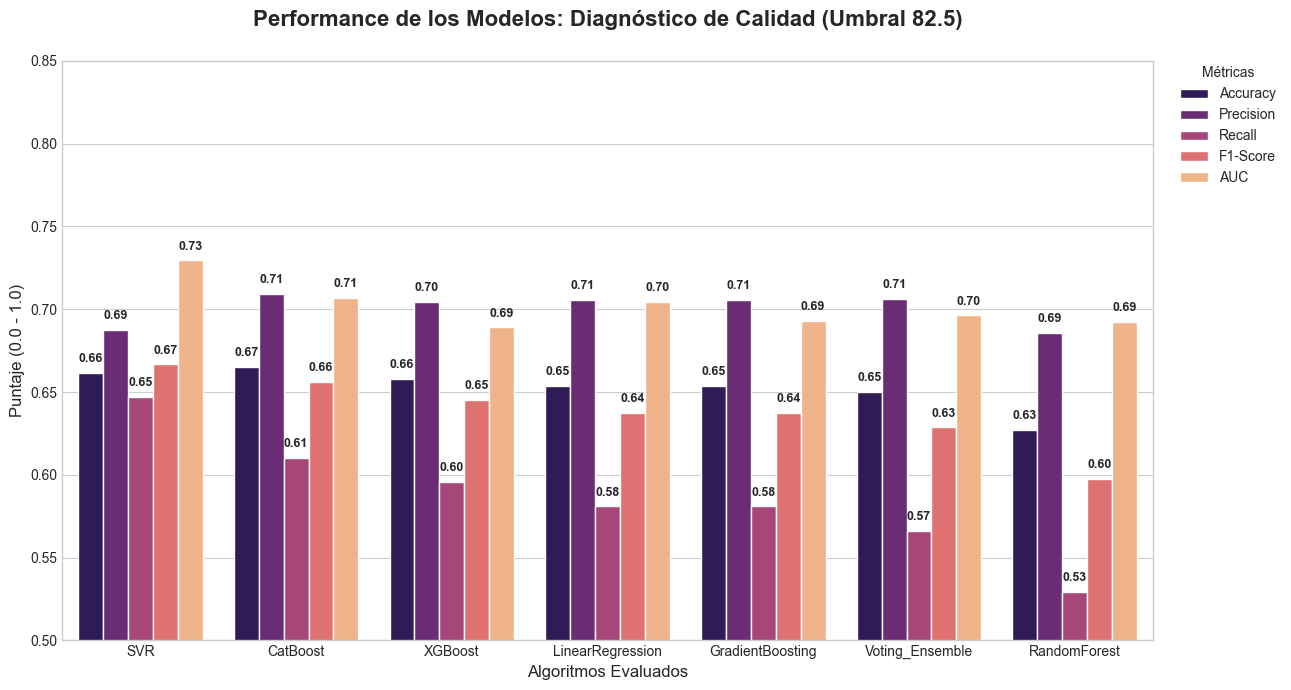

In [20]:
MODELS_DIR = '../models/prediction'
df = pd.read_csv('../data/processed/coffee_data_for_training.csv')
df = df[(df['Total.Cup.Points'] > 70) & (df['Total.Cup.Points'] < 92)]

target = 'Total.Cup.Points'
X = df.drop(columns=[target])
y = df[target]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

umbral = 82.5
y_test_bin = (y_test >= umbral).astype(int)

def obtener_metricas_binarias(nombre, y_cont):
    y_pred_bin = (y_cont >= umbral).astype(int)
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test_bin, y_pred_bin),
        'Precision': precision_score(y_test_bin, y_pred_bin),
        'Recall': recall_score(y_test_bin, y_pred_bin),
        'F1-Score': f1_score(y_test_bin, y_pred_bin),
        'AUC': roc_auc_score(y_test_bin, y_cont)
    }

resultados_finales = []
modelos_a_evaluar = ['SVR', 'CatBoost', 'LinearRegression', 'Voting_Ensemble', 'XGBoost', 'GradientBoosting', 'RandomForest']

for m_name in modelos_a_evaluar:
    path_model = os.path.join(MODELS_DIR, f'coffee_model_{m_name}.pkl')
    
    if os.path.exists(path_model):
        model = joblib.load(path_model)
        y_pred_cont = model.predict(X_test)
        
        res = obtener_metricas_binarias(m_name, y_pred_cont)
        resultados_finales.append(res)

df_res = pd.DataFrame(resultados_finales).sort_values(by='F1-Score', ascending=False)
df_melt = df_res.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(13, 7))
sns.set_style("whitegrid") 

ax = sns.barplot(
    data=df_melt, 
    x='Modelo', 
    y='Valor', 
    hue='Métrica', 
    palette='magma'
)

plt.title('Performance de los Modelos: Diagnóstico de Calidad (Umbral 82.5)', 
          fontsize=16, fontweight='bold', pad=25)
plt.ylim(0.5, 0.85)
plt.ylabel('Puntaje (0.0 - 1.0)', fontsize=12)
plt.xlabel('Algoritmos Evaluados', fontsize=12)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=9,
                fontweight='bold')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title='Métricas')

plt.tight_layout()
plt.show()

# 9. Curva ROC - AUC

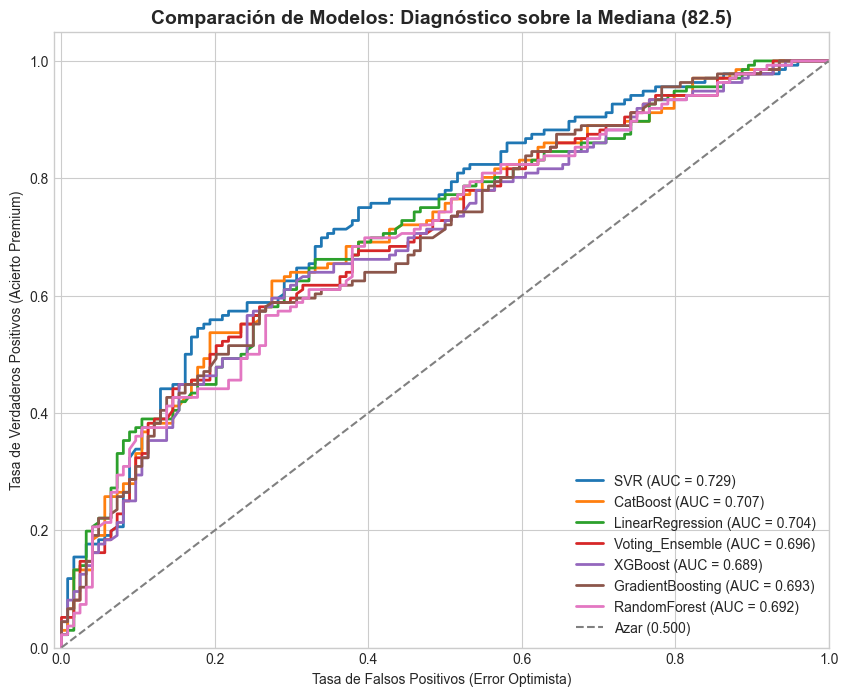


--- RANKING FINAL DE CLASIFICACIÓN ---
          Modelo  Accuracy  Precision   Recall  F1-Score      AUC
             SVR  0.661538   0.687500 0.647059  0.666667 0.729453
        CatBoost  0.665385   0.709402 0.610294  0.656126 0.706801
LinearRegression  0.653846   0.705357 0.580882  0.637097 0.704192
 Voting_Ensemble  0.650000   0.706422 0.566176  0.628571 0.696246
GradientBoosting  0.653846   0.705357 0.580882  0.637097 0.693163
    RandomForest  0.626923   0.685714 0.529412  0.597510 0.692214
         XGBoost  0.657692   0.704348 0.595588  0.645418 0.688982


In [ ]:
umbral = 82.5
MODELS_DIR = '../models/prediction'
modelos_a_evaluar = ['SVR', 'CatBoost', 'LinearRegression', 'Voting_Ensemble', 'XGBoost', 'GradientBoosting', 'RandomForest']

y_test_bin = (y_test >= umbral).astype(int)
resultados_lista = []

plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')

for name in modelos_a_evaluar:
    path = os.path.join(MODELS_DIR, f'coffee_model_{name}.pkl')
    
    if os.path.exists(path):
        model = joblib.load(path)
        y_score = model.predict(X_test) 
        y_pred_bin = (y_score >= umbral).astype(int) 
        
       
        fpr, tpr, _ = roc_curve(y_test_bin, y_score)
        roc_auc = auc(fpr, tpr)
        
        resultados_lista.append({
            'Modelo': name,
            'Accuracy': accuracy_score(y_test_bin, y_pred_bin),
            'Precision': precision_score(y_test_bin, y_pred_bin),
            'Recall': recall_score(y_test_bin, y_pred_bin),
            'F1-Score': f1_score(y_test_bin, y_pred_bin),
            'AUC': roc_auc
        })
        
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Azar (0.500)')
plt.xlim([-0.01, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Error Optimista)')
plt.ylabel('Tasa de Verdaderos Positivos (Acierto Premium)')
plt.title(f'Comparación de Modelos: Diagnóstico sobre la Mediana ({umbral})', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.show()

df_res = pd.DataFrame(resultados_lista).sort_values(by='AUC', ascending=False)
print("\n--- RANKING FINAL DE CLASIFICACIÓN ---")
print(df_res.to_string(index=False))